In [198]:
import numpy
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [3]:
df = pd.read_csv("spam.csv", encoding = "latin-1")

In [4]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
447,ham,I wont get concentration dear you know you are...,NaN,NaN,NaN
2509,ham,U wake up already? Wat u doing? U picking us u...,NaN,NaN,NaN
4293,spam,Kit Strip - you have been billed 150p. Netcoll...,NaN,NaN,NaN
4938,ham,Tomarrow i want to got to court. At &lt;DECIM...,NaN,NaN,NaN
2501,ham,No da..today also i forgot..,NaN,NaN,NaN


In [32]:
df.shape

(5572, 5)

In [33]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [5]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [41]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [4]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [5]:
df.sample(5)

,v1,v2
3263,ham,I will send them to your email. Do you mind &...
3887,ham,ok....take care.umma to you too...
4568,ham,At WHAT TIME should i come tomorrow
790,ham,This is hoping you enjoyed your game yesterday...
3351,ham,Call him and say you not coming today ok and t...


In [6]:
df.rename(columns = {'v1': 'label', 'v2': 'message'}, inplace = True) 

In [8]:
df.sample(5)

,label,message
852,ham,No da if you run that it activate the full ver...
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny
3065,spam,Get a brand new mobile phone by being an agent...
4635,ham,K k pa Had your lunch aha.
665,ham,En chikku nange bakra msg kalstiya..then had t...


In [9]:
df = df[['message', 'label']]

In [10]:
df.sample(5)

,message,label
3857,R u still working now?,ham
2418,"Madam,regret disturbance.might receive a refer...",ham
314,You made my day. Do have a great day too.,ham
5313,My sister going to earn more than me da.,ham
5376,I don't want you to leave. But i'm barely doin...,ham


In [11]:
le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])

In [13]:
df.sample(5)

,message,label
549,Ok give me 5 minutes I think I see her. BTW yo...,0
4785,Holy living christ what is taking you so long,0
3707,Free Top ringtone -sub to weekly ringtone-get ...,1
2013,Great News! Call FREEFONE 08006344447 to claim...,1
3606,I have no idea where you are,0


In [14]:
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [15]:
total_duplicates = df.duplicated().sum()
print(f"There are {total_duplicates} duplicate rows.")

There are 403 duplicate rows.


In [16]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows.head())


                                               message  label
102  As per your request 'Melle Melle (Oru Minnamin...      0
153  As per your request 'Melle Melle (Oru Minnamin...      0
206  As I entered my cabin my PA said, '' Happy B'd...      0
222                             Sorry, I'll call later      0
325                   No calls..messages..missed calls      0


In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(5169, 2)

## EDA

In [20]:
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

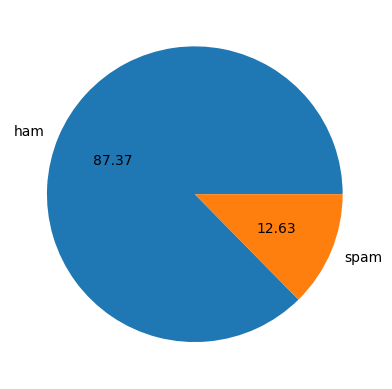

In [21]:
plt.pie(df['label'].value_counts(), labels = ['ham', 'spam'], autopct = "%0.2f")
plt.show()

In [133]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [22]:
df['num_char'] = df['message'].apply(len)
df.sample(5)

,message,label,num_char
124,ÌÏ predict wat time Ì_'ll finish buying?,0,40
1232,1's finish meeting call me.,0,27
3023,I love ya too but try and budget your money be...,0,90
216,Tired. I haven't slept well the past few nights.,0,48
185,Hello handsome ! Are you finding that job ? No...,0,152


In [24]:
from sklearn.feature_extraction.text import CountVectorizer

texts = [
    "I love AI",
    "AI is amazing"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(texts)

In [25]:
print(vectorizer.vocabulary_)

{'love': 3, 'ai': 0, 'is': 2, 'amazing': 1}


In [26]:
print(X.toarray())

[[1 0 0 1]
 [1 1 1 0]]


In [27]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ApriZon\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [29]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ApriZon\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

## Practicing NLTK stff

In [35]:
from nltk.tokenize import sent_tokenize, word_tokenize

text = "Hello there! My name is Dr. Turing. I teach at U.C. Berkeley."

sentences = sent_tokenize(text) 
words = word_tokenize(text)
print("Sentences")
print(sentences)
print("Words")
print(words)

Sentences
['Hello there!', 'My name is Dr. Turing.', 'I teach at U.C.', 'Berkeley.']
Words
['Hello', 'there', '!', 'My', 'name', 'is', 'Dr.', 'Turing', '.', 'I', 'teach', 'at', 'U.C', '.', 'Berkeley', '.']


## Implementing on dataset

In [38]:
df['num_words'] = df['message'].apply(lambda x: len(word_tokenize(x)))

In [41]:
df.sample(5)

,message,label,num_char,num_words
1071,URGENT! We are trying to contact U. Todays dra...,1,157,31
5520,No. I dont want to hear anything,0,32,8
2848,YOUR CHANCE TO BE ON A REALITY FANTASY SHOW ca...,1,151,33
3928,Yes. Nigh you cant aha.,0,23,7
565,"Ill call u 2mrw at ninish, with my address tha...",0,103,24


In [42]:
df['num_sent'] = df['message'].apply(lambda x: len(sent_tokenize(x)))
df.sample(5)

,message,label,num_char,num_words,num_sent
526,Today's Offer! Claim ur å£150 worth of discoun...,1,160,35,7
105,Thanks a lot for your wishes on my birthday. T...,0,95,19,2
1844,Da is good good player.why he is unsold.,0,40,9,1
4869,Dip's cell dead. So i m coming with him. U bet...,0,82,21,3
820,Good afternoon starshine! How's my boytoy? Doe...,0,131,32,5


In [43]:
df[['num_char', 'num_words', 'num_sent']].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [47]:
df[df['label'] == 0].describe()

,label,num_char,num_words,num_sent
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [48]:
#For HAM Messages
df[df['label'] == 0][['num_char', 'num_words', 'num_sent']].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [49]:
#FOR SPAM MESSAGES
df[df['label'] == 1][['num_char', 'num_words', 'num_sent']].describe()

,num_char,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: ylabel='Count'>

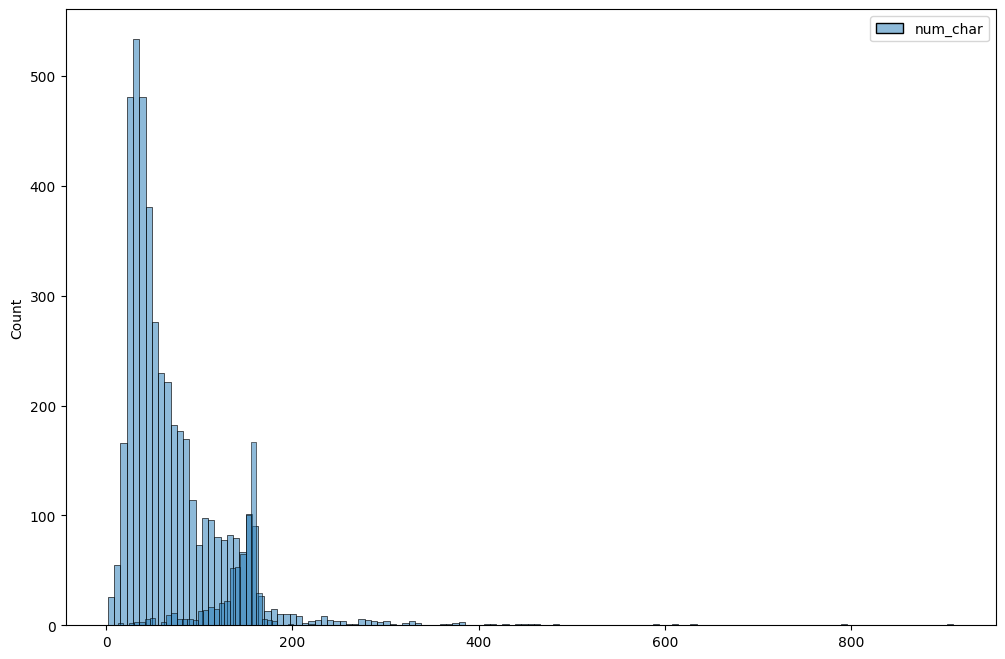

In [66]:
plt.figure(figsize = (12,8))
sns.histplot(df[df['label'] == 0][['num_char']])
sns.histplot(df[df['label'] == 1][['num_char']], color = 'red')

<Axes: ylabel='Count'>

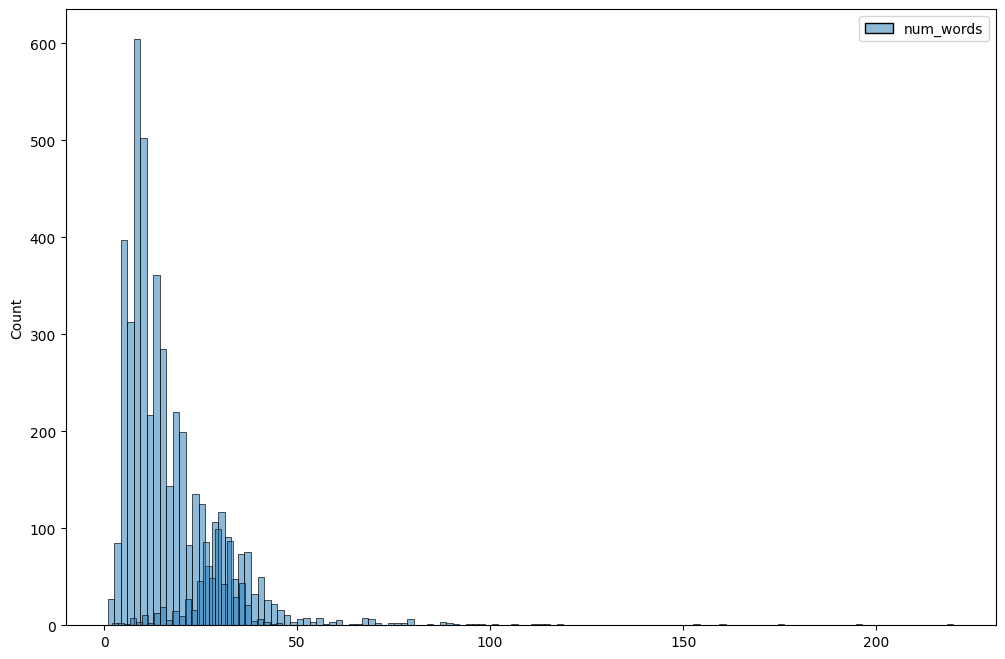

In [68]:
plt.figure(figsize = (12,8))
sns.histplot(df[df['label'] == 0][['num_words']])
sns.histplot(df[df['label'] == 1][['num_words']], color = 'red')

<Axes: ylabel='Count'>

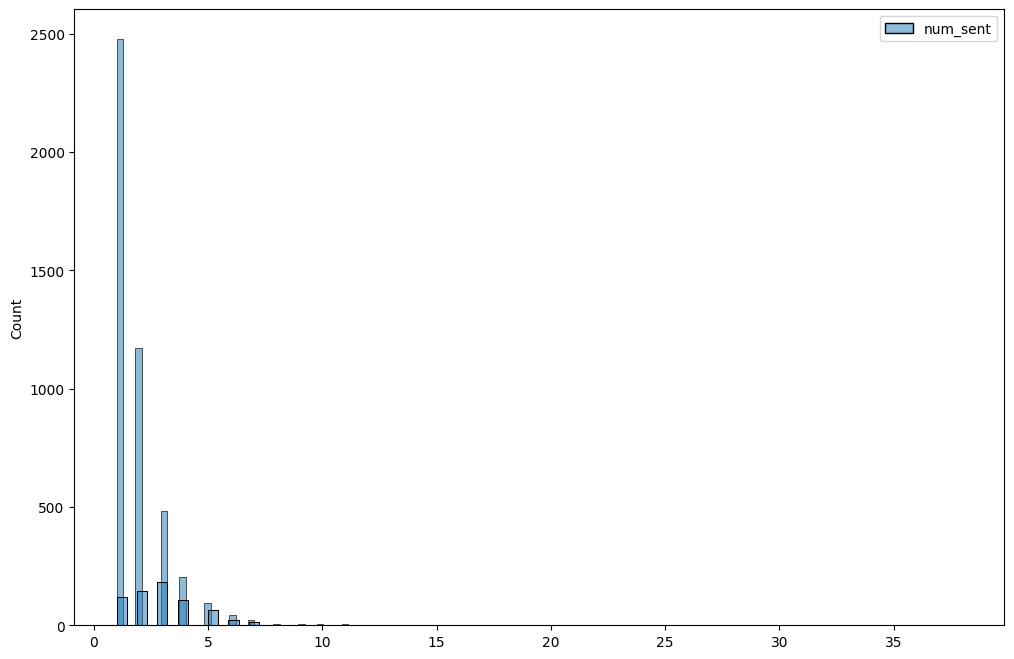

In [70]:
plt.figure(figsize = (12,8))
sns.histplot(df[df['label'] == 0][['num_sent']])
sns.histplot(df[df['label'] == 1][['num_sent']], color = 'red')

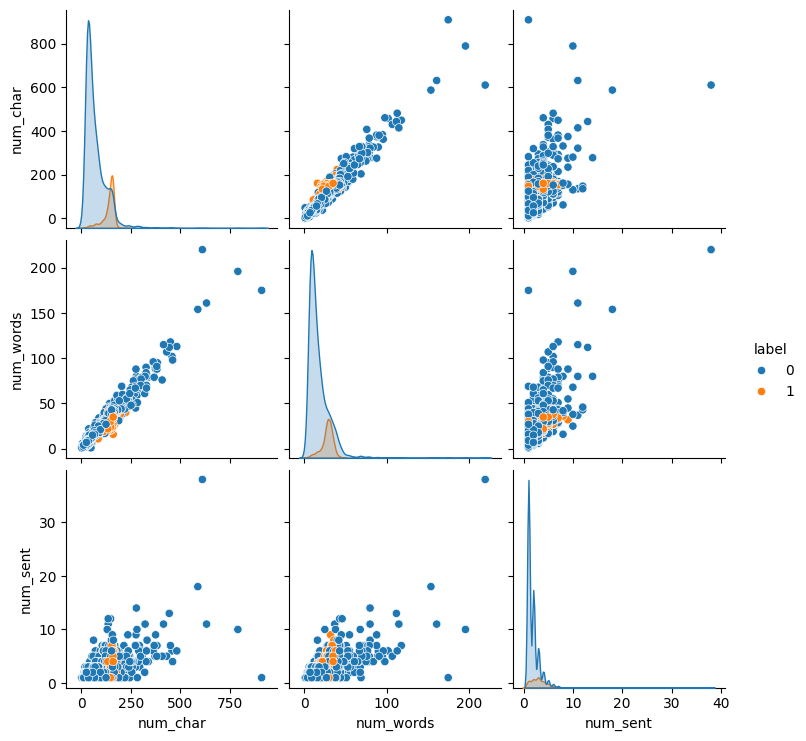

In [72]:
sns.pairplot(df, hue = 'label')

<Axes: >

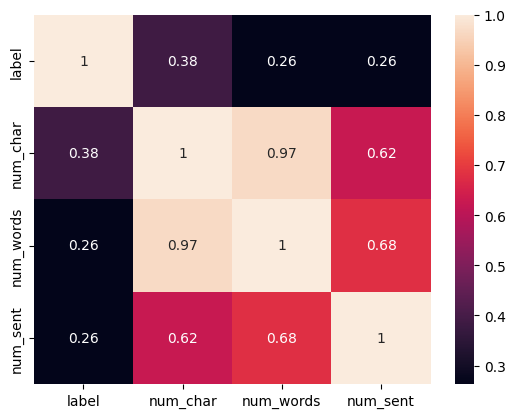

In [81]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot = True)

## Text Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [129]:
stemmer = PorterStemmer()
cached_stopwords = set(stopwords.words('english')) 

In [130]:

def text_preprocessing(text):
    text = text.lower()
    tokens = word_tokenize(text)
    
    cleaned_tokens = []
    for word in tokens:    
        if word.isalnum() and word not in cached_stopwords:
            cleaned_tokens.append(stemmer.stem(word))
        

    return " ".join(cleaned_tokens)

In [102]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ApriZon\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [131]:
print(text_preprocessing("Reading?"))

read


In [104]:
stopwords.words('english')
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [107]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ApriZon\AppData\Roaming\nltk_data...


True

## Stemming and Lemitization Example

In [108]:
import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words = ["running", "runs", "ran", "flies", "flying", "better", "studiing", "leaves"]

print(f"{'Original Word':<15} | {'Stemming (Porter)':<20} | {'Lemmatization (WordNet)':<25}")
print("-" * 65)

for word in words:
    stemmed_word = stemmer.stem(word)
    lemmatized_word = lemmatizer.lemmatize(word)
    
    print(f"{word:<15} | {stemmed_word:<20} | {lemmatized_word:<25}")

Original Word   | Stemming (Porter)    | Lemmatization (WordNet)  
-----------------------------------------------------------------
running         | run                  | running                  
runs            | run                  | run                      
ran             | ran                  | ran                      
flies           | fli                  | fly                      
flying          | fli                  | flying                   
better          | better               | better                   
studiing        | studi                | studiing                 
leaves          | leav                 | leaf                     


In [132]:
df['transformed_message'] = df['message'].apply(text_preprocessing)

In [133]:
df.sample(5)

,message,label,num_char,num_words,num_sent,transformed_message
3251,Come to medical college at 7pm ......forward i...,0,50,10,1,come medic colleg 7pm forward da
4610,Wat time Ì_ finish?,0,19,5,1,wat time finish
67,Urgent UR awarded a complimentary trip to Euro...,1,161,34,3,urgent ur award complimentari trip eurodisinc ...
5305,\Hi missed your Call and my mumHas beendroppin...,0,99,22,2,miss call mumha beendrop red wine theplac adress
3957,So i could kiss and feel you next to me...,0,42,11,1,could kiss feel next


In [144]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

spam_wc = wc.generate(df[df['label'] == 1]['transformed_message'].str.cat(sep=' '))

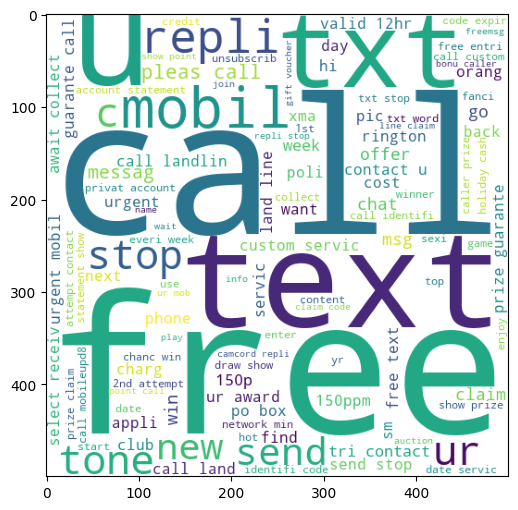

In [146]:
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)           

In [147]:
ham_wc = wc.generate(df[df['label'] == 0]['transformed_message'].str.cat(sep=' '))

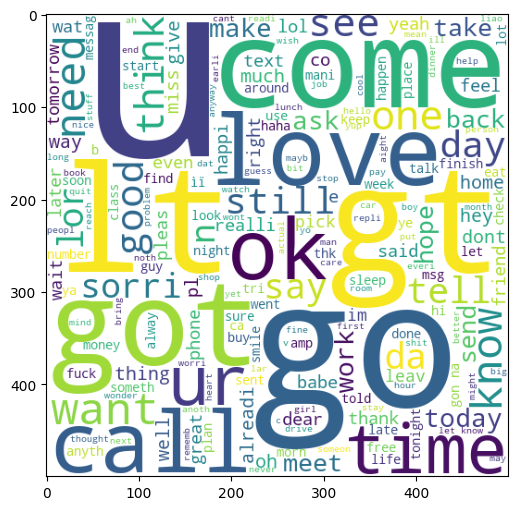

In [148]:
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

In [154]:
spam_corpus = []
for message in df[df['label'] == 1]['transformed_message'].tolist():
    for word in message.split():
        spam_corpus.append(word)

In [155]:
print(spam_corpus)

['free', 'entri', '2', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', '21st', 'may', 'text', 'fa', '87121', 'receiv', 'entri', 'question', 'std', 'txt', 'rate', 'c', 'appli', '08452810075over18', 'freemsg', 'hey', 'darl', '3', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chg', 'send', 'rcv', 'winner', 'valu', 'network', 'custom', 'select', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl341', 'valid', '12', 'hour', 'mobil', '11', 'month', 'u', 'r', 'entitl', 'updat', 'latest', 'colour', 'mobil', 'camera', 'free', 'call', 'mobil', 'updat', 'co', 'free', '08002986030', 'six', 'chanc', 'win', 'cash', '100', 'pound', 'txt', 'csh11', 'send', 'cost', '6day', 'tsandc', 'appli', 'repli', 'hl', '4', 'info', 'urgent', '1', 'week', 'free', 'membership', 'prize', 'jackpot', 'txt', 'word', 'claim', '81010', 'c', 'lccltd', 'pobox', '4403ldnw1a7rw18', 'xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'messag', 'click',

In [156]:
from collections import Counter
Counter(spam_corpus)

Counter({'call': 320,
         'free': 191,
         '2': 155,
         'txt': 141,
         'text': 122,
         'u': 119,
         'ur': 119,
         'mobil': 114,
         'stop': 104,
         'repli': 103,
         'claim': 98,
         '4': 97,
         'prize': 82,
         'get': 74,
         'new': 64,
         'servic': 64,
         'tone': 63,
         'send': 60,
         'urgent': 57,
         'nokia': 57,
         'contact': 56,
         'award': 55,
         'phone': 52,
         'cash': 51,
         'pleas': 51,
         'week': 49,
         'win': 48,
         'c': 45,
         'collect': 45,
         'min': 45,
         'custom': 42,
         'messag': 42,
         'guarante': 42,
         'per': 41,
         'chat': 38,
         'tri': 37,
         'msg': 35,
         'draw': 35,
         'number': 35,
         'cs': 35,
         'show': 33,
         'today': 33,
         'offer': 33,
         'line': 33,
         'go': 32,
         'receiv': 31,
         'want': 3

In [159]:
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


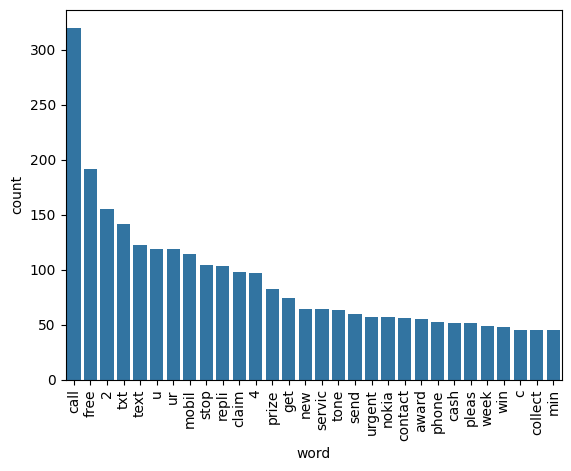

In [171]:
top30 = Counter(spam_corpus).most_common(30)
df_top30 = pd.DataFrame(top30, columns=['word', 'count'])
sns.barplot(data=df_top30, x='word', y='count')
plt.xticks(rotation = 'vertical')
plt.show()

In [172]:
ham_corpus = []
for message in df[df['label'] == 0]['transformed_message'].tolist():
    for word in message.split():
        ham_corpus.append(word)

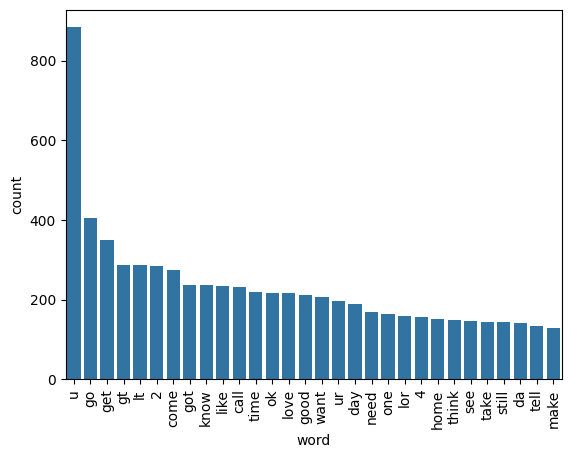

In [173]:
top30 = Counter(ham_corpus).most_common(30)
df_top30 = pd.DataFrame(top30, columns=['word', 'count'])
sns.barplot(data=df_top30, x='word', y='count')
plt.xticks(rotation = 'vertical')
plt.show()

### Building The Model

In [318]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()
tfidfV = TfidfVectorizer(max_features = 2000)

In [319]:
X = tfidfV.fit_transform(df['transformed_message']).toarray()
X.shape
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 2000))

In [273]:
tfidfV.vocabulary_   

{'go': np.int64(352),
 'point': np.int64(661),
 'crazi': np.int64(199),
 'avail': np.int64(78),
 'great': np.int64(363),
 'world': np.int64(972),
 'la': np.int64(460),
 'cine': np.int64(160),
 'got': np.int64(360),
 'wat': np.int64(929),
 'ok': np.int64(611),
 'lar': np.int64(465),
 'joke': np.int64(443),
 'wif': np.int64(952),
 'free': np.int64(327),
 'entri': np.int64(274),
 'wkli': np.int64(964),
 'comp': np.int64(178),
 'win': np.int64(955),
 'final': np.int64(310),
 'may': np.int64(530),
 'text': np.int64(842),
 'receiv': np.int64(697),
 'question': np.int64(682),
 'txt': np.int64(891),
 'rate': np.int64(688),
 'appli': np.int64(67),
 'dun': np.int64(256),
 'say': np.int64(739),
 'earli': np.int64(258),
 'alreadi': np.int64(52),
 'nah': np.int64(579),
 'think': np.int64(848),
 'goe': np.int64(354),
 'usf': np.int64(908),
 'live': np.int64(496),
 'around': np.int64(71),
 'though': np.int64(852),
 'freemsg': np.int64(328),
 'hey': np.int64(391),
 'darl': np.int64(210),
 'week': np.i

In [274]:
Y = df['label'].values

In [320]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split (
    X,Y,test_size = 0.2
)

In [321]:
gnb_model = GaussianNB()
mnb_model = MultinomialNB()
bnb_model = BernoulliNB()

## Gaussian Model

In [322]:
gnb_model.fit(x_train, y_train)
y_pred = gnb_model.predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Precision: ", precision_score(y_test,y_pred))
print("Confusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

Accuracy:  0.8317214700193424
Precision:  0.4409722222222222
Confusion Matrix

[[733 161]
 [ 13 127]]


## Multinomial Model

In [324]:
mnb_model.fit(x_train, y_train)

print("On Train Data")
y_pred = mnb_model.predict(x_train)
print("Accuracy: ",accuracy_score(y_train,y_pred))
print("Precision: ", precision_score(y_train,y_pred))
print("Confusion Matrix\n")
print(confusion_matrix(y_train,y_pred))



print("On Test Data")
y_pred = mnb_model.predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Precision: ", precision_score(y_test,y_pred))
print("Confusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

On Train Data
Accuracy:  0.9784764207980653
Precision:  0.9930232558139535
Confusion Matrix

[[3619    3]
 [  86  427]]
On Test Data
Accuracy:  0.9816247582205029
Precision:  1.0
Confusion Matrix

[[894   0]
 [ 19 121]]


## BinomialModel

In [325]:
bnb_model.fit(x_train, y_train)
y_pred = bnb_model.predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Precision: ", precision_score(y_test,y_pred))
print("Confusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

Accuracy:  0.9845261121856866
Precision:  0.9558823529411765
Confusion Matrix

[[888   6]
 [ 10 130]]


In [326]:
bnb_model.fit(x_train, y_train)
y_pred = bnb_model.predict(x_train)
print("Accuracy: ",accuracy_score(y_train,y_pred))
print("Precision: ", precision_score(y_train,y_pred))
print("Confusion Matrix\n")
print(confusion_matrix(y_train,y_pred))

Accuracy:  0.9857315598548972
Precision:  0.9913419913419913
Confusion Matrix

[[3618    4]
 [  55  458]]


In [327]:
import joblib

joblib.dump(mnb_model,'Model.joblib')
joblib.dump(tfidfV,'Vectorizer.joblib')

['Vectorizer.joblib']